# Nodal LMP vs. Redispatch Battery-Siting Score — 2013 50-node run

**Goal.** The battery siting score is a *proxy* for the locational price signal that
Germany's single bidding zone hides. This notebook uses the **real** nodal marginal
prices from the PyPSA `de-nodal-2013` run (50 clusters, **25 German nodes**, 3-hourly,
weather year 2013) to check whether the locations the proxy scores as high-value are
the same ones where the nodal model shows a strong battery-arbitrage / congestion signal.

Compared file: `battery_siting_score/out/grid_siting_scores_20260629_155333.csv`
(50 MW / 4 h reference battery, `dV_proxy_eur_per_year` = locational value premium).

Because resolutions differ (siting = 4,593 cells on a 0.1° grid; PyPSA = 25 DE nodes),
each siting cell is assigned to its **nearest PyPSA node**, then aggregated.
Only the **ranking** is comparable, not absolute €.

In [1]:
import netCDF4 as nc, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
plt.rcParams['figure.dpi']=110; plt.rcParams['font.size']=10

NET   = "de-nodal-2013/networks/base_s_50_elec_.nc"
SITE  = "../battery_siting_score/out/grid_siting_scores_20260629_155333.csv"
PMW, DUR = 50.0, 4.0          # reference battery: 50 MW / 4 h

## 1. Load PyPSA nodal prices and keep German nodes

In [2]:
ds = nc.Dataset(NET)
rs = lambda n:(list(nc.chartostring(ds.variables[n][:]))
               if ds.variables[n][:].dtype.kind in 'SU' else ds.variables[n][:])
bus=[str(b) for b in rs('buses_i')]; X,Y=rs('buses_x'),rs('buses_y')
ctry=[str(c) for c in rs('buses_country')]
mp=np.array(ds.variables['buses_t_marginal_price'][:]); mp_i=[str(b) for b in rs('buses_t_marginal_price_i')]
ds.close()
if mp.shape[0]==len(mp_i): mp=mp.T
price=pd.DataFrame(mp,columns=mp_i)
de=[b for b,c in zip(bus,ctry) if c=='DE']
T=price.shape[0]; dt=8760/T; steps_per_day=int(round(24/dt))
print(f"snapshots={T}  dt={dt:.1f} h  steps/day={steps_per_day}  DE nodes={len(de)}")
price[de].describe().T[['mean','std','min','max']].round(2)

snapshots=2920  dt=3.0 h  steps/day=8  DE nodes=25


,mean,std,min,max
DE0 0AC,29.19,6.25,19.85,80.04
DE0 10AC,27.96,5.90,16.91,79.70
DE0 11AC,30.07,10.42,14.44,85.94
DE0 12AC,24.68,7.15,2.89,79.92
DE0 13AC,31.29,7.40,23.75,83.19
DE0 14AC,30.13,16.91,7.57,131.17
DE0 15AC,29.76,10.49,14.58,85.90
DE0 16AC,30.50,8.53,23.06,83.17
DE0 17AC,23.93,8.34,0.03,82.47
DE0 18AC,30.11,7.56,20.44,83.39


## 2. Per-node battery value from the nodal price

A dt-aware greedy arbitrage: each day, charge the cheapest steps (up to power limit
`PMW*dt` per step and energy cap `PMW*DUR`) and discharge the dearest steps. This is the
nodal-price analog of the siting score's `dV`. We also record price mean, volatility and
each node's congestion premium (deviation from the German mean price).

In [3]:
E_CAP=PMW*DUR; E_STEP=PMW*dt
def daily_arb(day):                      # day = array of step prices
    order=np.argsort(day)
    lo,hi=order[:len(order)//2], order[len(order)//2:][::-1]
    e=0.0; buy=0.0
    for s in lo:
        if e>=E_CAP: break
        q=min(E_STEP,E_CAP-e); buy+=q*day[s]; e+=q
    e=0.0; sell=0.0
    for s in hi:
        if e>=E_CAP: break
        q=min(E_STEP,E_CAP-e); sell+=q*day[s]; e+=q
    return sell-buy                      # € profit that day

recs=[]
for b in de:
    p=price[b].values[:T//steps_per_day*steps_per_day].reshape(-1,steps_per_day)
    prof=np.array([daily_arb(d) for d in p])
    arb=prof.sum()*(365/len(prof))       # €/yr
    i=bus.index(b)
    recs.append(dict(bus=b,x=float(X[i]),y=float(Y[i]),
                     mean_price=price[b].mean(),std_price=price[b].std(),
                     p95_p5_spread=np.percentile(price[b],95)-np.percentile(price[b],5),
                     arb_eur_yr=arb))
nod=pd.DataFrame(recs)
nod['congestion_premium']=nod['mean_price']-price[de].values.mean()
nod.sort_values('arb_eur_yr',ascending=False).round(2)

,bus,x,y,mean_price,std_price,p95_p5_spread,arb_eur_yr,congestion_premium
10,DE0 19AC,7.62,53.22,19.55,18.53,54.83,1260398.83,-9.03
5,DE0 14AC,10.27,52.26,30.13,16.91,52.90,983982.67,1.56
24,DE0 9AC,8.83,52.97,27.06,13.01,40.56,875701.13,-1.52
19,DE0 4AC,9.66,53.99,26.90,12.74,40.80,854804.42,-1.68
14,DE0 22AC,8.74,51.94,29.31,11.53,33.14,683711.58,0.74
18,DE0 3AC,11.78,52.00,23.27,8.97,31.51,655020.78,-5.31
11,DE0 1AC,7.45,51.79,30.18,10.66,29.99,627802.93,1.60
2,DE0 11AC,6.84,51.24,30.07,10.42,28.52,597456.41,1.49
6,DE0 15AC,9.48,51.22,29.76,10.49,28.75,597107.08,1.19
8,DE0 17AC,12.44,53.63,23.93,8.34,28.56,581654.12,-4.65


## 3. Aggregate the siting surface to the nearest PyPSA node

In [4]:
sit=pd.read_csv(SITE); print("siting grid cells:",len(sit))
nx,ny=nod['x'].values,nod['y'].values
sit['pypsa_bus']=[nod['bus'].values[((nx-lo)**2+(ny-la)**2).argmin()]
                  for lo,la in zip(sit['lon'],sit['lat'])]
agg=(sit.groupby('pypsa_bus')
        .agg(n_cells=('lon','size'),sit_V=('V_proxy_eur_per_year','mean'),
             sit_dV=('dV_proxy_eur_per_year','mean')).reset_index())
m=nod.merge(agg,left_on='bus',right_on='pypsa_bus').drop(columns='pypsa_bus')
m.sort_values('sit_dV',ascending=False).round(2)

siting grid cells: 4593


,bus,x,y,mean_price,std_price,p95_p5_spread,arb_eur_yr,congestion_premium,n_cells,sit_V,sit_dV
21,DE0 6AC,14.22,51.51,25.60,5.80,16.52,371899.43,-2.97,191,20222692.76,13800380.24
16,DE0 24AC,11.05,50.85,29.19,6.53,15.42,403732.47,0.62,172,18066268.41,11643955.89
6,DE0 15AC,9.48,51.22,29.76,10.49,28.75,597107.08,1.19,173,17509453.50,11087140.98
1,DE0 10AC,12.48,50.92,27.96,5.90,13.21,341747.44,-0.61,190,17180890.97,10758578.45
9,DE0 18AC,10.67,49.81,30.11,7.56,18.30,417417.86,1.54,207,16764816.79,10342504.26
20,DE0 5AC,8.73,50.09,30.47,9.45,24.54,514231.26,1.90,141,16344634.26,9922321.74
18,DE0 3AC,11.78,52.00,23.27,8.97,31.51,655020.78,-5.31,226,15730151.45,9307838.92
5,DE0 14AC,10.27,52.26,30.13,16.91,52.90,983982.67,1.56,249,14477427.46,8055114.94
3,DE0 12AC,13.47,52.59,24.68,7.15,23.75,491698.35,-3.89,277,14417662.36,7995349.84
8,DE0 17AC,12.44,53.63,23.93,8.34,28.56,581654.12,-4.65,311,13676643.92,7254331.40


## 4. Correlations across the 25 German nodes

In [5]:
pairs=[('arb_eur_yr','sit_dV'),('std_price','sit_dV'),('p95_p5_spread','sit_dV'),
       ('congestion_premium','sit_dV'),('arb_eur_yr','sit_V')]
rows=[]
for a,b in pairs:
    rho,ps=spearmanr(m[a],m[b]); r,pp=pearsonr(m[a],m[b])
    rows.append(dict(x=a,y=b,spearman=round(rho,3),spearman_p=round(ps,3),
                     pearson=round(r,3),pearson_p=round(pp,3)))
corr=pd.DataFrame(rows); corr

,x,y,spearman,spearman_p,pearson,pearson_p
0,arb_eur_yr,sit_dV,0.185,0.375,0.034,0.871
1,std_price,sit_dV,-0.131,0.533,-0.152,0.467
2,p95_p5_spread,sit_dV,0.008,0.971,-0.066,0.752
3,congestion_premium,sit_dV,-0.598,0.002,-0.314,0.127
4,arb_eur_yr,sit_V,0.185,0.375,0.034,0.871


## 5. Graphs

### 5a. Siting locational value per node (ranked)

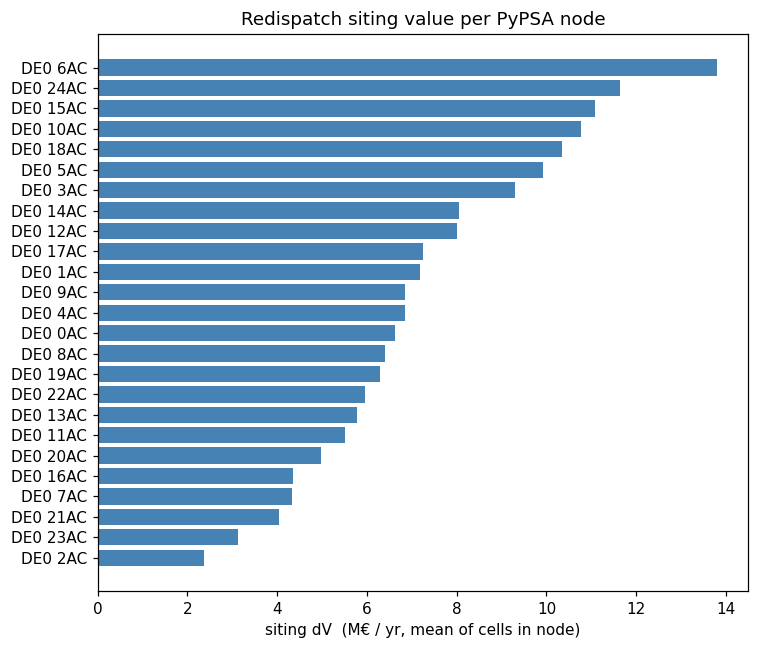

In [6]:
d=m.sort_values('sit_dV')
plt.figure(figsize=(7,6))
plt.barh(d['bus'],d['sit_dV']/1e6,color='steelblue')
plt.xlabel('siting dV  (M€ / yr, mean of cells in node)'); plt.title('Redispatch siting value per PyPSA node')
plt.tight_layout(); plt.show()

### 5b. Siting value vs. nodal-price battery value

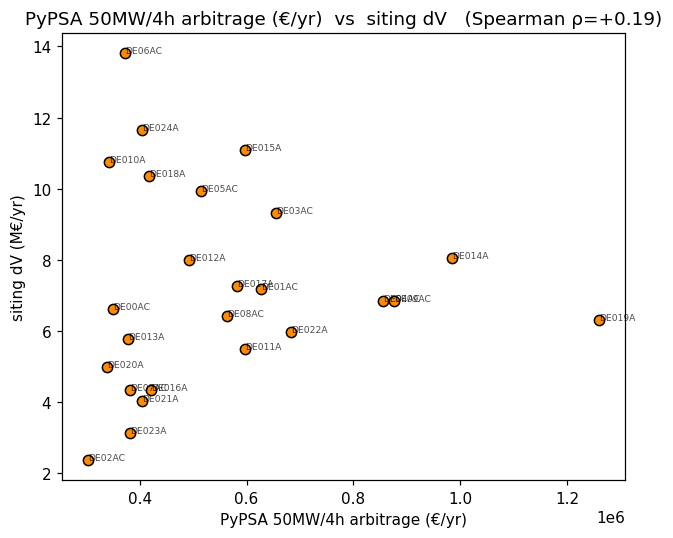

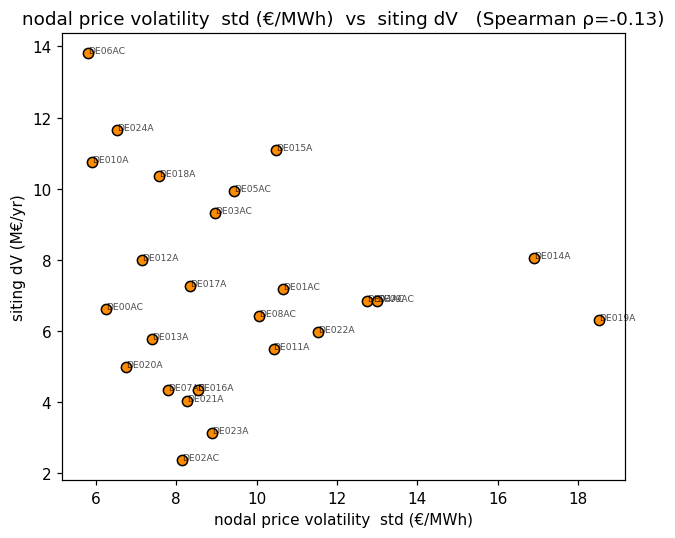

In [7]:
def scat(xc,yc,xl,yl):
    plt.figure(figsize=(6,5))
    plt.scatter(m[xc],m[yc]/1e6,c='darkorange',edgecolor='k',s=45)
    for _,r in m.iterrows(): plt.annotate(r['bus'].replace(' ','')[:6],(r[xc],r[yc]/1e6),fontsize=6,alpha=.7)
    rho,_=spearmanr(m[xc],m[yc])
    plt.xlabel(xl); plt.ylabel(yl); plt.title(f'{xl}  vs  siting dV   (Spearman ρ={rho:+.2f})')
    plt.tight_layout(); plt.show()
scat('arb_eur_yr','sit_dV','PyPSA 50MW/4h arbitrage (€/yr)','siting dV (M€/yr)')
scat('std_price','sit_dV','nodal price volatility  std (€/MWh)','siting dV (M€/yr)')

### 5c. Spatial pattern — siting value vs. nodal arbitrage side by side

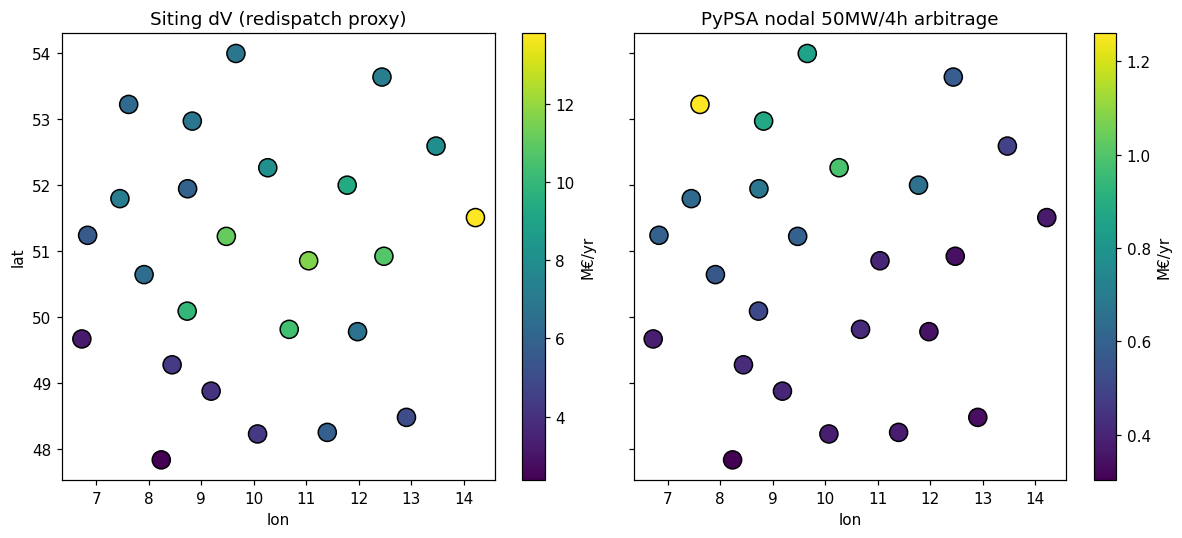

In [8]:
fig,ax=plt.subplots(1,2,figsize=(11,5),sharex=True,sharey=True)
for a,col,ttl in [(ax[0],'sit_dV','Siting dV (redispatch proxy)'),
                  (ax[1],'arb_eur_yr','PyPSA nodal 50MW/4h arbitrage')]:
    sc=a.scatter(m['x'],m['y'],c=m[col]/1e6,cmap='viridis',s=140,edgecolor='k')
    a.set_title(ttl); a.set_xlabel('lon'); fig.colorbar(sc,ax=a,label='M€/yr')
ax[0].set_ylabel('lat'); plt.tight_layout(); plt.show()

### 5d. Metric correlation heatmap

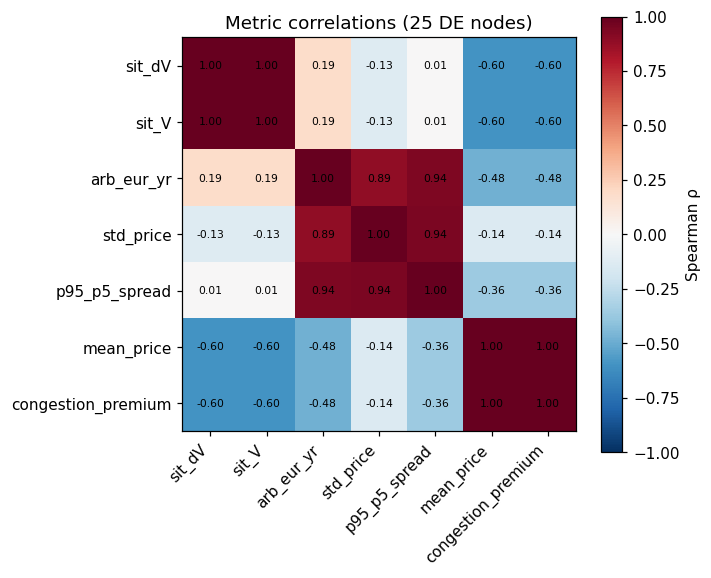

In [9]:
mc=m[['sit_dV','sit_V','arb_eur_yr','std_price','p95_p5_spread','mean_price','congestion_premium']].corr(method='spearman')
plt.figure(figsize=(6.5,5.5))
plt.imshow(mc,cmap='RdBu_r',vmin=-1,vmax=1)
plt.xticks(range(len(mc)),mc.columns,rotation=45,ha='right'); plt.yticks(range(len(mc)),mc.columns)
for i in range(len(mc)):
    for j in range(len(mc)): plt.text(j,i,f"{mc.iloc[i,j]:.2f}",ha='center',va='center',fontsize=7)
plt.colorbar(label='Spearman ρ'); plt.title('Metric correlations (25 DE nodes)'); plt.tight_layout(); plt.show()

## 6. Save results & takeaways

In [10]:
m.round(3).to_csv("nodal_vs_siting_comparison_2013.csv",index=False)
print("saved -> nodal_vs_siting_comparison_2013.csv")

saved -> nodal_vs_siting_comparison_2013.csv


**Reading the results**

- Compare **ranks**, not euros: siting `dV` is calibrated to BNetzA redispatch cost
  (~100 €/MWh); the PyPSA LMP spreads here are only a few €/MWh, so absolute levels differ
  by orders of magnitude by construction.
- A **positive** Spearman ρ between siting `dV` and nodal **arbitrage / volatility** means the
  redispatch proxy is pointing at the same high-value locations the nodal model does — the
  core validation claim for the seminar.
- Watch the **congestion_premium** sign: high *mean-price* nodes (southern demand centres)
  are not necessarily high *volatility* nodes, so mean price and battery value can diverge.
- This 2013 run gives 25 DE nodes (vs 10 in the hourly run) → a more meaningful correlation,
  but at 3-hourly resolution it **understates intraday spread**, so treat arbitrage € as a
  lower bound.